# 1. Imports

In [1]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11



pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Data Loading & Merging

In [2]:
base_path = ''
for dirname, _, filenames in os.walk('/kaggle/input'):
    if 'train_FD001.txt' in filenames:
        base_path = dirname
        break

if not base_path:
    raise ValueError("Dataset files not found. Please ensure the dataset is added to the notebook.")

train_files = ['train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt']
sensor_real_names = [
    'T2_FanInletTemp', 'T24_LPCOutletTemp', 'T30_HPCOutletTemp', 'T50_LPTOutletTemp',
    'P2_FanInletPress', 'P15_BypassPress', 'P30_HPCOutletPress', 'Nf_PhysicalFanSpeed',
    'Nc_PhysicalCoreSpeed', 'epr_EnginePressRatio', 'Ps30_HPCStaticPress', 'phi_FuelFlowRatio',
    'NRf_CorrectedFanSpeed', 'NRc_CorrectedCoreSpeed', 'BPR_BypassRatio', 'farB_BurnerFuelAirRatio',
    'htBleed_BleedEnthalpy', 'Nf_dmd_DemandedFanSpeed', 'PCNfR_dmd_DemandedCorFanSpeed',
    'W31_HPTCoolantBleed', 'W32_LPTCoolantBleed'
]
columns = ['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + sensor_real_names

dfs = []
for file in train_files:
    file_path = os.path.join(base_path, file)
    if os.path.exists(file_path):
        temp_df = pd.read_csv(file_path, sep='\s+', names=columns)
        temp_df['dataset_id'] = file.split('.')[0]
        dfs.append(temp_df)

final_df = pd.concat(dfs, ignore_index=True)
cols = ['dataset_id'] + [c for c in final_df.columns if c != 'dataset_id']
df = final_df[cols].copy()

df["unit_id"] = "train_" + df["dataset_id"].astype(str) + "_" + df["engine_id"].astype(str)

print("Data merged and unit_id created successfully!")
print(f"Total dimensions: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Total distinct engine units across all 4 merged subsets: {df['unit_id'].nunique()}")
print("-" * 60)
display(df.head())

Data merged and unit_id created successfully!
Total dimensions: 160359 rows and 28 columns
Total distinct engine units across all 4 merged subsets: 709
------------------------------------------------------------


,dataset_id,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,T2_FanInletTemp,T24_LPCOutletTemp,T30_HPCOutletTemp,T50_LPTOutletTemp,P2_FanInletPress,P15_BypassPress,P30_HPCOutletPress,Nf_PhysicalFanSpeed,Nc_PhysicalCoreSpeed,epr_EnginePressRatio,Ps30_HPCStaticPress,phi_FuelFlowRatio,NRf_CorrectedFanSpeed,NRc_CorrectedCoreSpeed,BPR_BypassRatio,farB_BurnerFuelAirRatio,htBleed_BleedEnthalpy,Nf_dmd_DemandedFanSpeed,PCNfR_dmd_DemandedCorFanSpeed,W31_HPTCoolantBleed,W32_LPTCoolantBleed,unit_id
0,train_FD001,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,train_train_FD001_1
1,train_FD001,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,train_train_FD001_1
2,train_FD001,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,train_train_FD001_1
3,train_FD001,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,train_train_FD001_1
4,train_FD001,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,train_train_FD001_1


# 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160359 entries, 0 to 160358
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dataset_id                     160359 non-null  object 
 1   engine_id                      160359 non-null  int64  
 2   cycle                          160359 non-null  int64  
 3   op_setting_1                   160359 non-null  float64
 4   op_setting_2                   160359 non-null  float64
 5   op_setting_3                   160359 non-null  float64
 6   T2_FanInletTemp                160359 non-null  float64
 7   T24_LPCOutletTemp              160359 non-null  float64
 8   T30_HPCOutletTemp              160359 non-null  float64
 9   T50_LPTOutletTemp              160359 non-null  float64
 10  P2_FanInletPress               160359 non-null  float64
 11  P15_BypassPress                160359 non-null  float64
 12  P30_HPCOutletPress            

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_id,160359.0,105.553758,72.867325,1.0000,44.00000,89.0000,164.0000,260.0000
cycle,160359.0,123.331338,83.538146,1.0000,57.00000,114.0000,173.0000,543.0000
op_setting_1,160359.0,17.211973,16.527988,-0.0087,0.00130,19.9981,35.0015,42.0080
op_setting_2,160359.0,0.410004,0.367938,-0.0006,0.00020,0.6200,0.8400,0.8420
op_setting_3,160359.0,95.724344,12.359044,60.0000,100.00000,100.0000,100.0000,100.0000
T2_FanInletTemp,160359.0,485.840890,30.420388,445.0000,449.44000,489.0500,518.6700,518.6700
T24_LPCOutletTemp,160359.0,597.361022,42.478516,535.4800,549.96000,605.9300,642.3400,645.1100
T30_HPCOutletTemp,160359.0,1467.035653,118.175261,1242.6700,1357.36000,1492.8100,1586.5900,1616.9100
T50_LPTOutletTemp,160359.0,1260.956434,136.300073,1023.7700,1126.83000,1271.7400,1402.2000,1441.4900
P2_FanInletPress,160359.0,9.894999,4.265554,3.9100,5.48000,9.3500,14.6200,14.6200


# 4. Exploratory Data Analysis

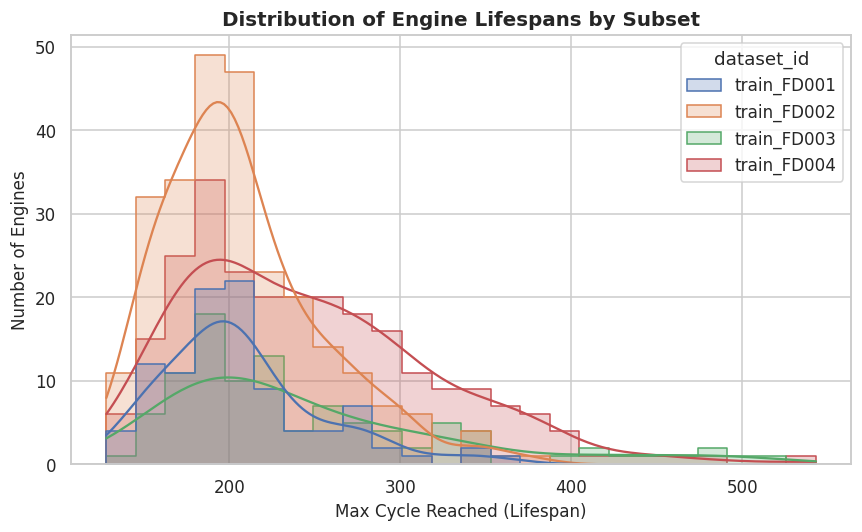

In [5]:
max_cycles = df.groupby(["dataset_id", "unit_id"])["cycle"].max().reset_index(name="max_cycle")

plt.figure(figsize=(8, 5))
sns.histplot(data=max_cycles, x="max_cycle", hue="dataset_id", kde=True, element="step")
plt.title("Distribution of Engine Lifespans by Subset")
plt.xlabel("Max Cycle Reached (Lifespan)")
plt.ylabel("Number of Engines")
plt.tight_layout()
plt.show()

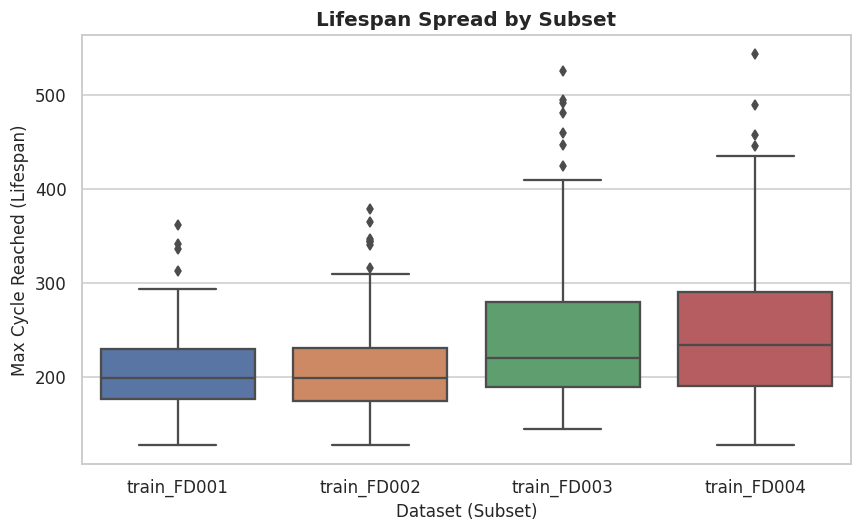

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=max_cycles, x="dataset_id", y="max_cycle")
plt.title("Lifespan Spread by Subset")
plt.xlabel("Dataset (Subset)")
plt.ylabel("Max Cycle Reached (Lifespan)")
plt.tight_layout()
plt.show()

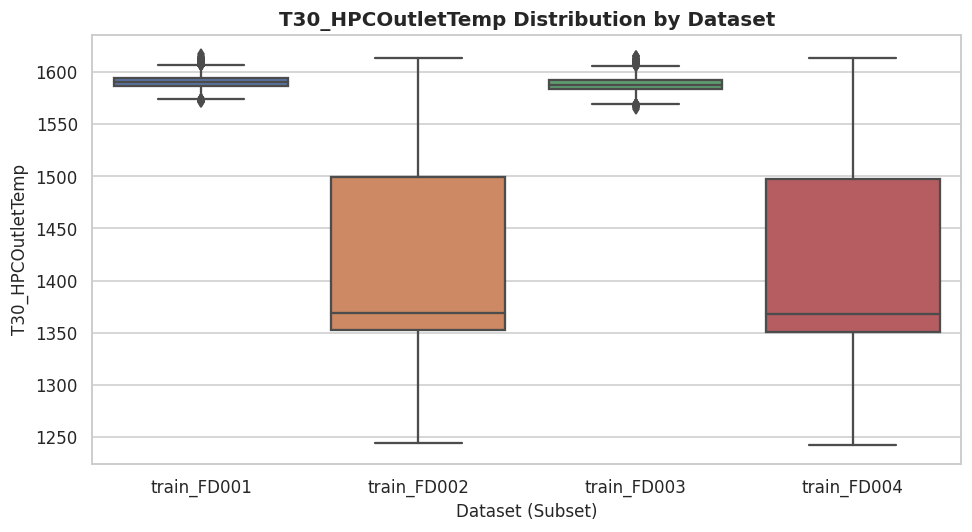

In [7]:
sensor_col = "T30_HPCOutletTemp"

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="dataset_id", y=sensor_col)
plt.title(f"{sensor_col} Distribution by Dataset")
plt.xlabel("Dataset (Subset)")
plt.ylabel(sensor_col)
plt.tight_layout()
plt.show()

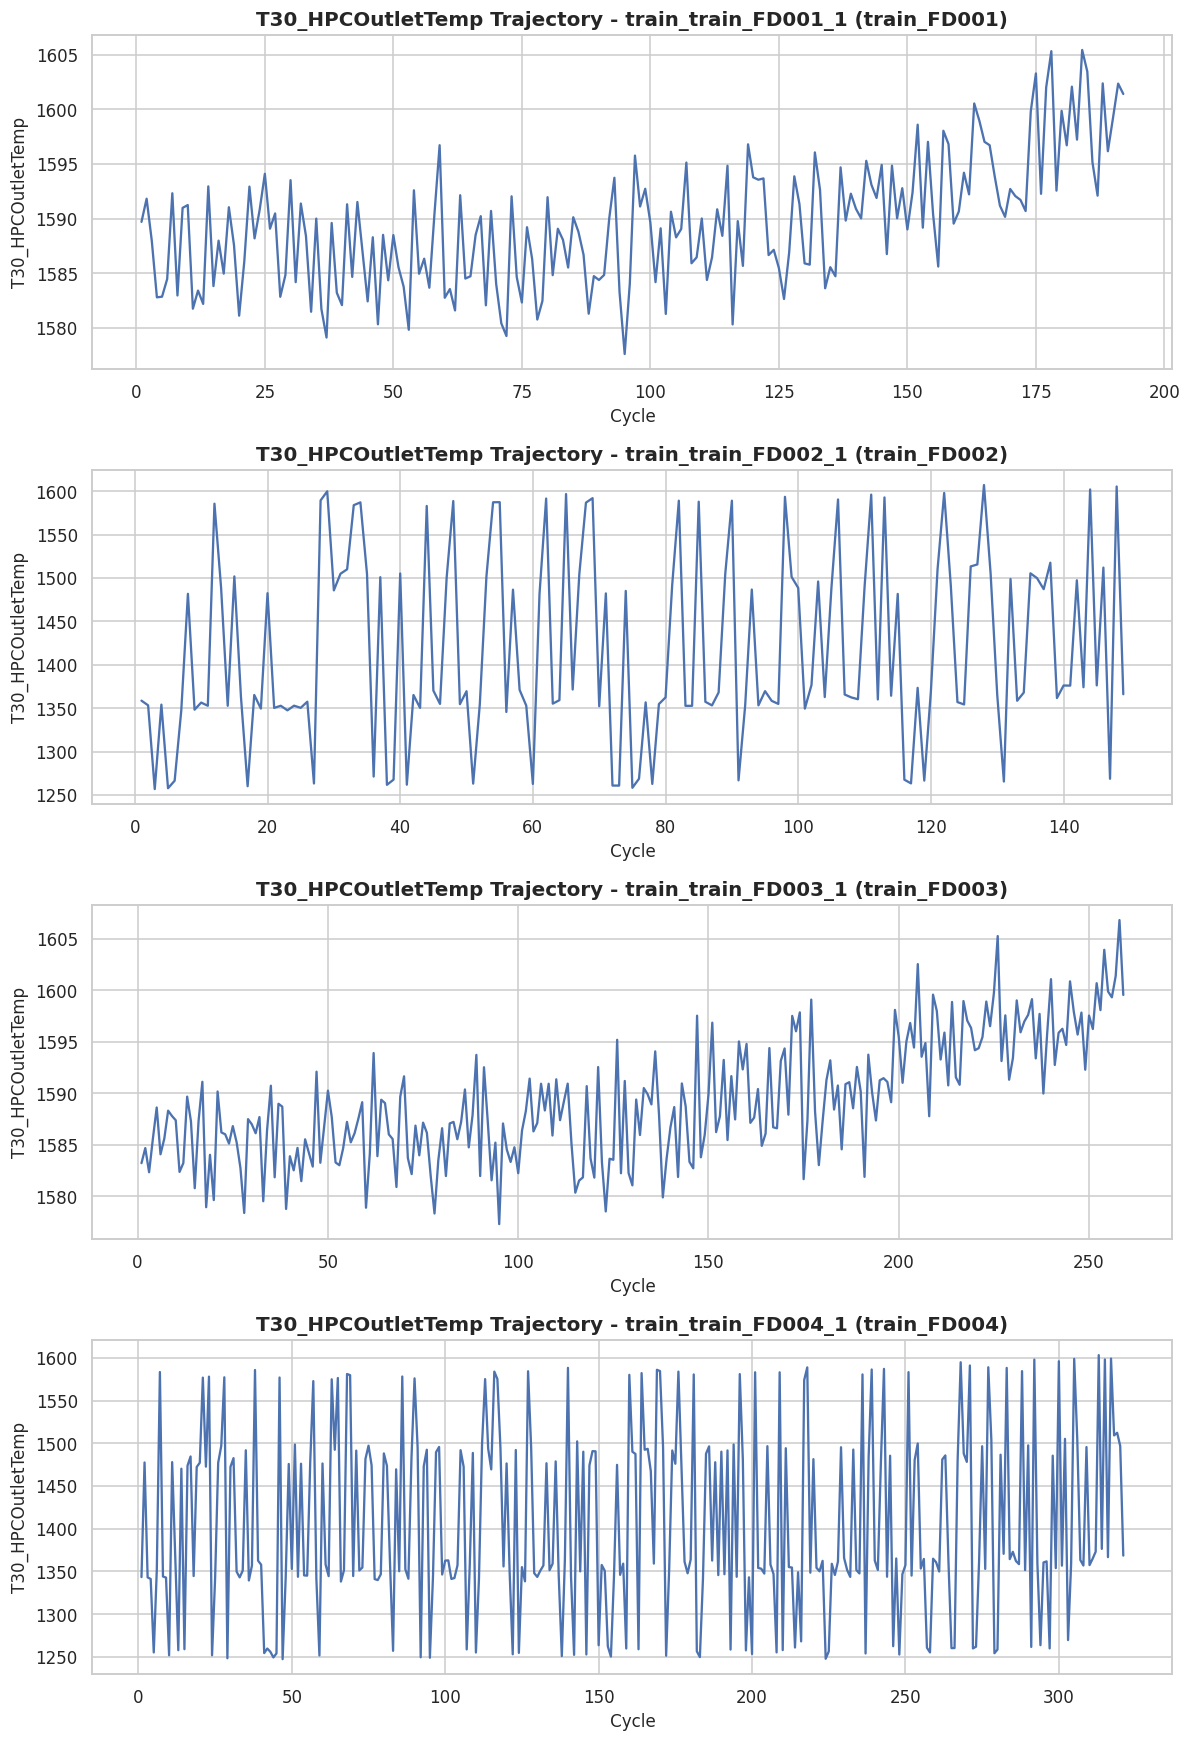

In [8]:
sample_ids = {ds: df.loc[df["dataset_id"] == ds, "unit_id"].iloc[0] for ds in df["dataset_id"].unique()}

fig, axes = plt.subplots(len(sample_ids), 1, figsize=(11, 4 * len(sample_ids)))
if len(sample_ids) == 1:
    axes = [axes]

for ax, (ds, uid) in zip(axes, sample_ids.items()):
    unit_df = df.loc[df["unit_id"] == uid].sort_values("cycle")
    ax.plot(unit_df["cycle"], unit_df[sensor_col], linewidth=1.5)
    ax.set_title(f"{sensor_col} Trajectory - {uid} ({ds})")
    ax.set_xlabel("Cycle")
    ax.set_ylabel(sensor_col)

plt.tight_layout()
plt.show()

# 5. Data Cleaning

No missing values found in the merged dataset.
Sensors with variance < 1e-06: None


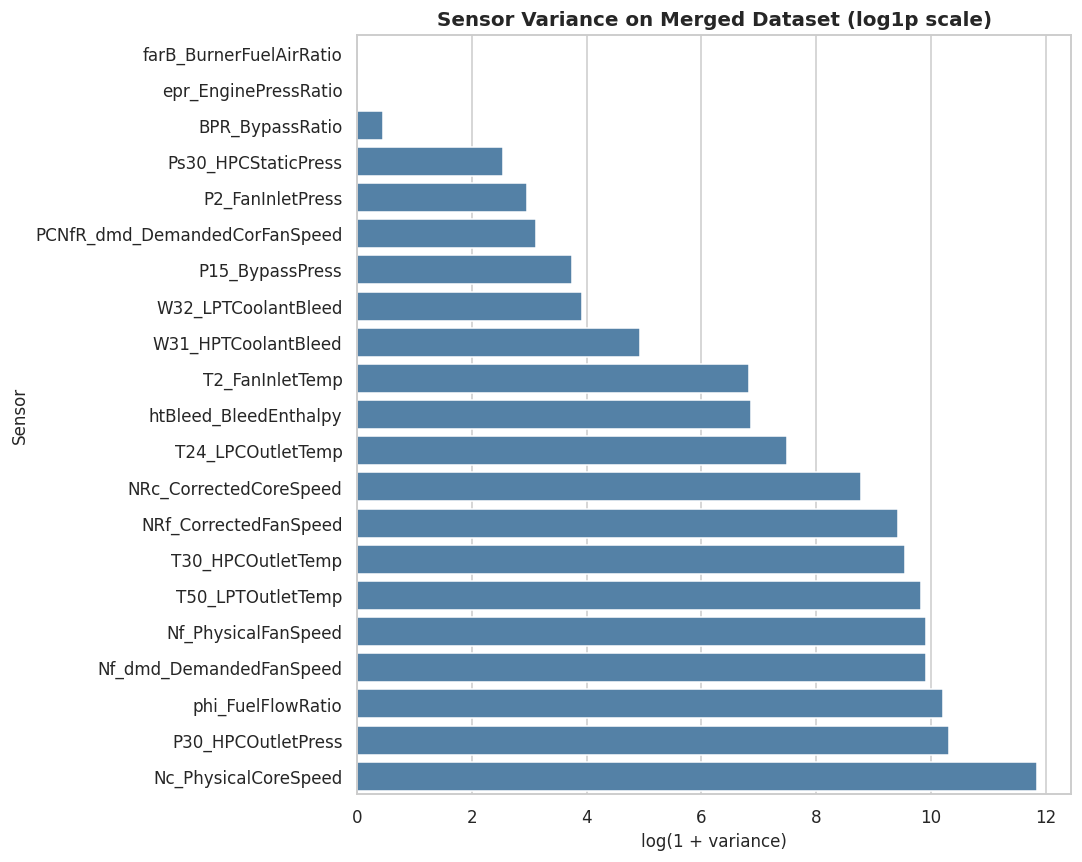

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("No missing values found in the merged dataset." if missing.empty else f"Missing values detected:\n{missing}")

meta_cols = {"dataset_id", "engine_id", "unit_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"}
protected_cols = {"op_setting_1", "op_setting_2", "op_setting_3"}
sensor_cols = [c for c in df.columns if c not in meta_cols and pd.api.types.is_numeric_dtype(df[c])]

variance_report = df[sensor_cols].var().sort_values().reset_index()
variance_report.columns = ["sensor", "variance"]

near_zero_threshold = 1e-6
near_zero_sensors = variance_report.loc[variance_report["variance"] < near_zero_threshold, "sensor"].tolist()
print(f"Sensors with variance < {near_zero_threshold}: {near_zero_sensors or 'None'}")

plt.figure(figsize=(10, 8))
sns.barplot(
    data=variance_report.assign(log_variance=np.log1p(variance_report["variance"])),
    y="sensor", x="log_variance", color="steelblue"
)
plt.title("Sensor Variance on Merged Dataset (log1p scale)")
plt.xlabel("log(1 + variance)")
plt.ylabel("Sensor")
plt.tight_layout()
plt.show()

In [10]:
assert not (protected_cols & set(near_zero_sensors)), "An operating setting was flagged as near-zero variance."

df = df.drop(columns=near_zero_sensors)
sensor_cols = [c for c in sensor_cols if c not in near_zero_sensors]

print(f"Dropped {len(near_zero_sensors)} constant sensor(s): {near_zero_sensors}")
print(f"Remaining sensor columns: {len(sensor_cols)} | Dataframe shape: {df.shape}")

Dropped 0 constant sensor(s): []
Remaining sensor columns: 21 | Dataframe shape: (160359, 28)


# 6. Feature Engineering (RUL, Rolling Features, Correlation Filtering)

In [11]:
df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
df["RUL"] = df.groupby("unit_id")["cycle"].transform("max") - df["cycle"]

display(df[["unit_id", "cycle", "RUL"]].head(10))

,unit_id,cycle,RUL
0,train_train_FD001_1,1,191
1,train_train_FD001_1,2,190
2,train_train_FD001_1,3,189
3,train_train_FD001_1,4,188
4,train_train_FD001_1,5,187
5,train_train_FD001_1,6,186
6,train_train_FD001_1,7,185
7,train_train_FD001_1,8,184
8,train_train_FD001_1,9,183
9,train_train_FD001_1,10,182


In [12]:
RUL_CLIP = 125
df["RUL"] = df["RUL"].clip(upper=RUL_CLIP)

print(f"RUL range after clipping: [{df['RUL'].min()}, {df['RUL'].max()}]")
print(f"Rows at the clipped ceiling: {(df['RUL'] == RUL_CLIP).mean() * 100:.2f}%")

RUL range after clipping: [0, 125]
Rows at the clipped ceiling: 44.73%


In [13]:
WINDOW = 5
rolling_feature_cols = []

grouped = df.groupby("unit_id")
for col in sensor_cols:
    mean_col, std_col = f"{col}_roll_mean{WINDOW}", f"{col}_roll_std{WINDOW}"
    df[mean_col] = grouped[col].transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
    df[std_col] = grouped[col].transform(lambda x: x.rolling(WINDOW, min_periods=1).std())
    rolling_feature_cols += [mean_col, std_col]

print(f"Created {len(rolling_feature_cols)} rolling features ({len(sensor_cols)} sensors x mean/std).")

Created 42 rolling features (21 sensors x mean/std).


In [14]:
df[rolling_feature_cols] = df.groupby("unit_id")[rolling_feature_cols].transform(lambda x: x.bfill())

print(f"Remaining NaNs in rolling features: {df[rolling_feature_cols].isnull().sum().sum()}")

Remaining NaNs in rolling features: 0


In [15]:
meta_cols = {"dataset_id", "engine_id", "unit_id", "cycle"}
feature_cols = [c for c in df.columns if c not in meta_cols and c != "RUL"]

corr_matrix = df[feature_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

CORR_THRESHOLD = 0.95
to_drop = {col for col in upper.columns if col not in protected_cols and (upper[col] > CORR_THRESHOLD).any()}

df = df.drop(columns=list(to_drop))
feature_cols = [c for c in feature_cols if c not in to_drop]

print(f"Dropped {len(to_drop)} highly correlated feature(s): {sorted(to_drop)}")
print(f"Final feature count: {len(feature_cols)} | Dataframe shape: {df.shape}")

Dropped 53 highly correlated feature(s): ['BPR_BypassRatio', 'BPR_BypassRatio_roll_mean5', 'BPR_BypassRatio_roll_std5', 'NRc_CorrectedCoreSpeed_roll_std5', 'NRf_CorrectedFanSpeed', 'Nc_PhysicalCoreSpeed', 'Nc_PhysicalCoreSpeed_roll_mean5', 'Nc_PhysicalCoreSpeed_roll_std5', 'Nf_PhysicalFanSpeed_roll_mean5', 'Nf_dmd_DemandedFanSpeed', 'Nf_dmd_DemandedFanSpeed_roll_mean5', 'Nf_dmd_DemandedFanSpeed_roll_std5', 'P15_BypassPress', 'P15_BypassPress_roll_mean5', 'P15_BypassPress_roll_std5', 'P2_FanInletPress', 'P2_FanInletPress_roll_mean5', 'P2_FanInletPress_roll_std5', 'P30_HPCOutletPress', 'P30_HPCOutletPress_roll_mean5', 'P30_HPCOutletPress_roll_std5', 'PCNfR_dmd_DemandedCorFanSpeed', 'PCNfR_dmd_DemandedCorFanSpeed_roll_mean5', 'PCNfR_dmd_DemandedCorFanSpeed_roll_std5', 'Ps30_HPCStaticPress', 'Ps30_HPCStaticPress_roll_mean5', 'Ps30_HPCStaticPress_roll_std5', 'T24_LPCOutletTemp', 'T24_LPCOutletTemp_roll_mean5', 'T24_LPCOutletTemp_roll_std5', 'T2_FanInletTemp', 'T30_HPCOutletTemp', 'T30_HPCOu

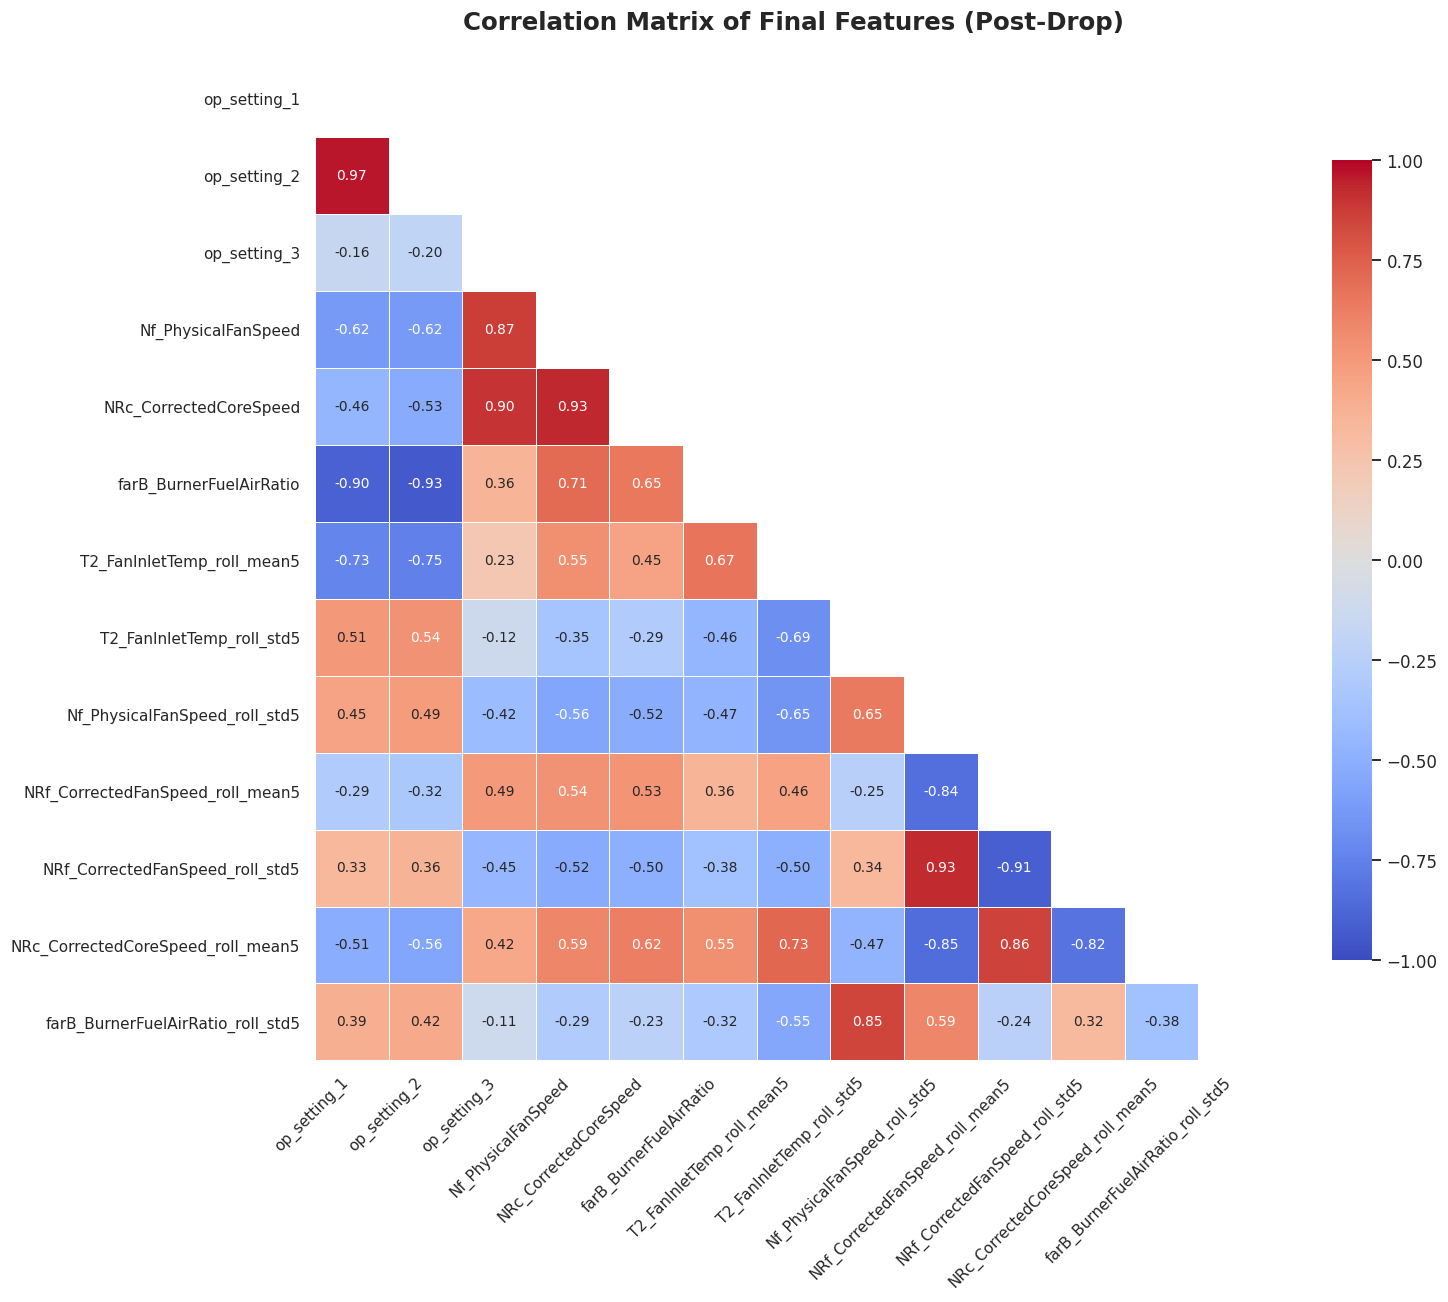

In [16]:
plt.figure(figsize=(14, 12))

final_corr_matrix = df[feature_cols].corr()
mask = np.triu(np.ones_like(final_corr_matrix, dtype=bool))

sns.heatmap(
    final_corr_matrix, 
    mask=mask, 
    cmap="coolwarm", 
    annot=True, 
    fmt=".2f", 
    annot_kws={"size": 9},
    linewidths=0.5, 
    vmin=-1, 
    vmax=1, 
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Final Features (Post-Drop)", fontsize=16, weight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 7. Train/Test Split & Scaling

In [17]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["unit_id"]))

train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
assert not set(train_df["unit_id"]) & set(test_df["unit_id"]), "Data leakage detected between train and test units."

X_train_unscaled, y_train = train_df[feature_cols].reset_index(drop=True), train_df["RUL"].reset_index(drop=True)
X_test_unscaled, y_test = test_df[feature_cols].reset_index(drop=True), test_df["RUL"].reset_index(drop=True)

print(f"Train: {X_train_unscaled.shape[0]} rows, {train_df['unit_id'].nunique()} units")
print(f"Test:  {X_test_unscaled.shape[0]} rows, {test_df['unit_id'].nunique()} units")

Train: 129029 rows, 567 units
Test:  31330 rows, 142 units


In [18]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_unscaled), columns=feature_cols, index=X_train_unscaled.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_unscaled), columns=feature_cols, index=X_test_unscaled.index)

print(f"Scaling complete. X_train_scaled: {X_train_scaled.shape}, X_test_scaled: {X_test_scaled.shape}")

Scaling complete. X_train_scaled: (129029, 13), X_test_scaled: (31330, 13)


In [19]:
df.head()

,dataset_id,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,Nf_PhysicalFanSpeed,NRc_CorrectedCoreSpeed,farB_BurnerFuelAirRatio,unit_id,RUL,T2_FanInletTemp_roll_mean5,T2_FanInletTemp_roll_std5,Nf_PhysicalFanSpeed_roll_std5,NRf_CorrectedFanSpeed_roll_mean5,NRf_CorrectedFanSpeed_roll_std5,NRc_CorrectedCoreSpeed_roll_mean5,farB_BurnerFuelAirRatio_roll_std5
0,train_FD001,1,1,-0.0007,-0.0004,100.0,2388.06,8138.62,0.03,train_train_FD001_1,125,518.67,0.0,0.014142,2388.020,0.035355,8138.620000,0.0
1,train_FD001,1,2,0.0019,-0.0003,100.0,2388.04,8131.49,0.03,train_train_FD001_1,125,518.67,0.0,0.014142,2388.045,0.035355,8135.055000,0.0
2,train_FD001,1,3,-0.0043,0.0003,100.0,2388.08,8133.23,0.03,train_train_FD001_1,125,518.67,0.0,0.020000,2388.040,0.026458,8134.446667,0.0
3,train_FD001,1,4,0.0007,0.0000,100.0,2388.11,8133.83,0.03,train_train_FD001_1,125,518.67,0.0,0.029861,2388.050,0.029439,8134.292500,0.0
4,train_FD001,1,5,-0.0019,-0.0002,100.0,2388.06,8133.80,0.03,train_train_FD001_1,125,518.67,0.0,0.026458,2388.048,0.025884,8134.194000,0.0


In [20]:
df.shape

(160359, 18)

# 8. Model Training

In [21]:
lr_model = LinearRegression()
start = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start

lr_train_pred, lr_test_pred = lr_model.predict(X_train_scaled), lr_model.predict(X_test_scaled)
print(f"Linear Regression trained in {lr_train_time:.3f}s | Coefficients: {len(lr_model.coef_)}")

Linear Regression trained in 0.072s | Coefficients: 13


In [22]:
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=25, random_state=42)
start = time.time()
dt_model.fit(X_train_unscaled, y_train)
dt_train_time = time.time() - start

dt_train_pred, dt_test_pred = dt_model.predict(X_train_unscaled), dt_model.predict(X_test_unscaled)
print(f"Decision Tree trained in {dt_train_time:.3f}s | Depth: {dt_model.get_depth()} | Leaves: {dt_model.get_n_leaves()}")

Decision Tree trained in 0.941s | Depth: 10 | Leaves: 584


In [23]:
rf_model = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1)
start = time.time()
rf_model.fit(X_train_unscaled, y_train)
rf_train_time = time.time() - start

rf_train_pred, rf_test_pred = rf_model.predict(X_train_unscaled), rf_model.predict(X_test_unscaled)
print(f"Random Forest trained in {rf_train_time:.3f}s | Trees: {rf_model.n_estimators}")

Random Forest trained in 69.440s | Trees: 200


In [24]:
xgb_model = XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
)
start = time.time()
xgb_model.fit(X_train_unscaled, y_train)
xgb_train_time = time.time() - start

xgb_train_pred, xgb_test_pred = xgb_model.predict(X_train_unscaled), xgb_model.predict(X_test_unscaled)
print(f"XGBoost trained in {xgb_train_time:.3f}s | Rounds: {xgb_model.n_estimators}")

XGBoost trained in 12.993s | Rounds: 200


In [25]:
results = {
    "Linear Regression": {"model": lr_model, "y_train_pred": lr_train_pred, "y_test_pred": lr_test_pred, "train_time_sec": lr_train_time},
    "Decision Tree": {"model": dt_model, "y_train_pred": dt_train_pred, "y_test_pred": dt_test_pred, "train_time_sec": dt_train_time},
    "Random Forest": {"model": rf_model, "y_train_pred": rf_train_pred, "y_test_pred": rf_test_pred, "train_time_sec": rf_train_time},
    "XGBoost": {"model": xgb_model, "y_train_pred": xgb_train_pred, "y_test_pred": xgb_test_pred, "train_time_sec": xgb_train_time},
}

for name, r in results.items():
    print(f"{name:<20} trained in {r['train_time_sec']:.3f}s")

Linear Regression    trained in 0.072s
Decision Tree        trained in 0.941s
Random Forest        trained in 69.440s
XGBoost              trained in 12.993s


# 9. Model Evaluation

In [26]:
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

metrics_rows = []
for name, r in results.items():
    train_rmse, train_mae, train_r2 = compute_metrics(y_train, r["y_train_pred"])
    test_rmse, test_mae, test_r2 = compute_metrics(y_test, r["y_test_pred"])
    metrics_rows.append({
        "Model": name,
        "Train_RMSE": train_rmse, "Test_RMSE": test_rmse,
        "Train_MAE": train_mae, "Test_MAE": test_mae,
        "Train_R2": train_r2, "Test_R2": test_r2,
        "Overfit_Gap_RMSE": test_rmse - train_rmse,
    })

metrics_df = pd.DataFrame(metrics_rows).set_index("Model")
metrics_df.round(3)

,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Overfit_Gap_RMSE
Model,,,,,,,
Linear Regression,36.372,37.412,30.156,30.640,0.221,0.183,1.040
Decision Tree,25.333,25.534,18.567,18.807,0.622,0.619,0.202
Random Forest,14.651,21.951,10.443,15.904,0.874,0.719,7.300
XGBoost,21.220,22.051,15.748,16.313,0.735,0.716,0.831


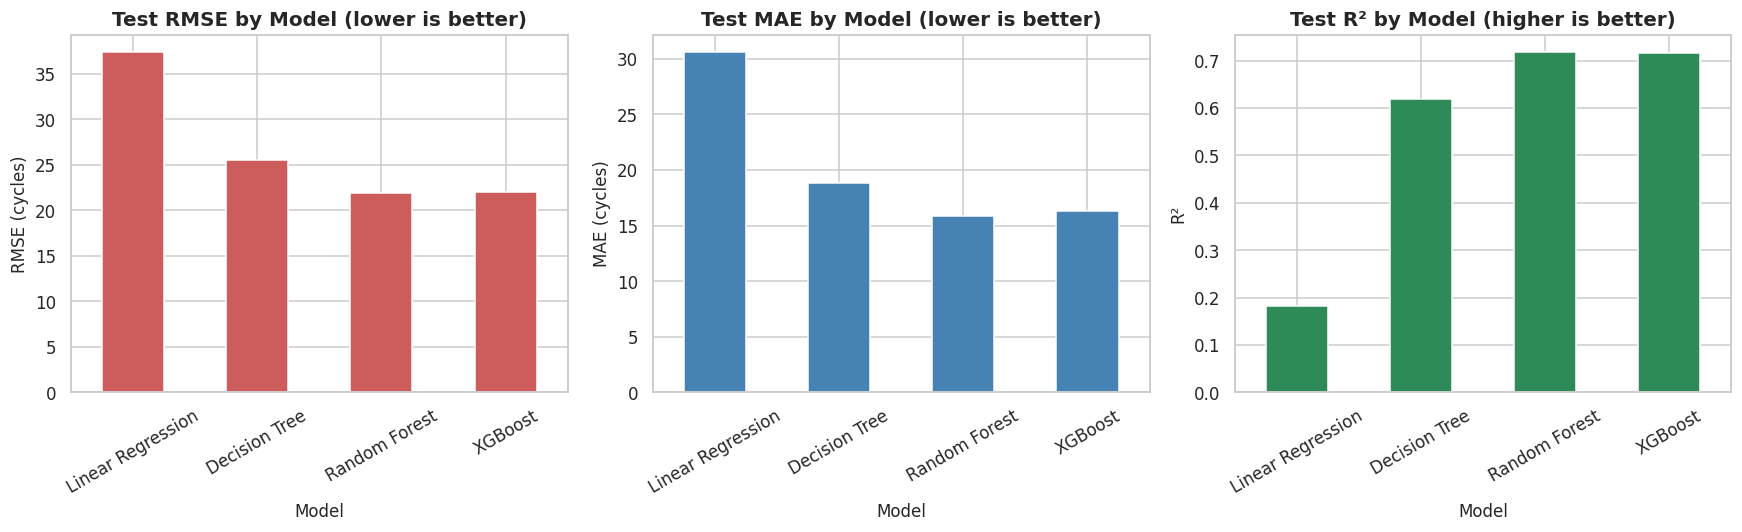

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_df["Test_RMSE"].plot(kind="bar", ax=axes[0], color="indianred", title="Test RMSE by Model (lower is better)")
metrics_df["Test_MAE"].plot(kind="bar", ax=axes[1], color="steelblue", title="Test MAE by Model (lower is better)")
metrics_df["Test_R2"].plot(kind="bar", ax=axes[2], color="seagreen", title="Test R\u00b2 by Model (higher is better)")

for ax, ylabel in zip(axes, ["RMSE (cycles)", "MAE (cycles)", "R\u00b2"]):
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

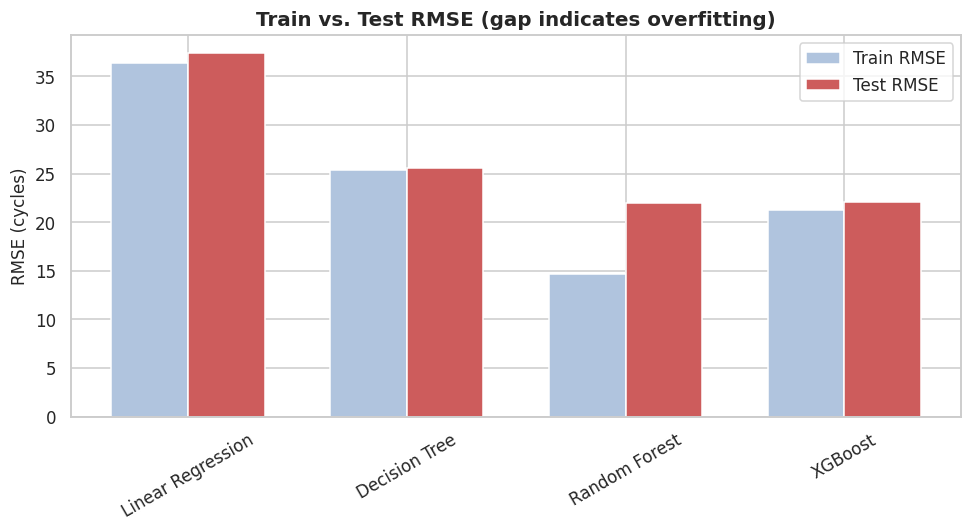

In [28]:
x = np.arange(len(metrics_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, metrics_df["Train_RMSE"], width, label="Train RMSE", color="lightsteelblue")
plt.bar(x + width / 2, metrics_df["Test_RMSE"], width, label="Test RMSE", color="indianred")
plt.xticks(x, metrics_df.index, rotation=30)
plt.ylabel("RMSE (cycles)")
plt.title("Train vs. Test RMSE (gap indicates overfitting)")
plt.legend()
plt.tight_layout()
plt.show()

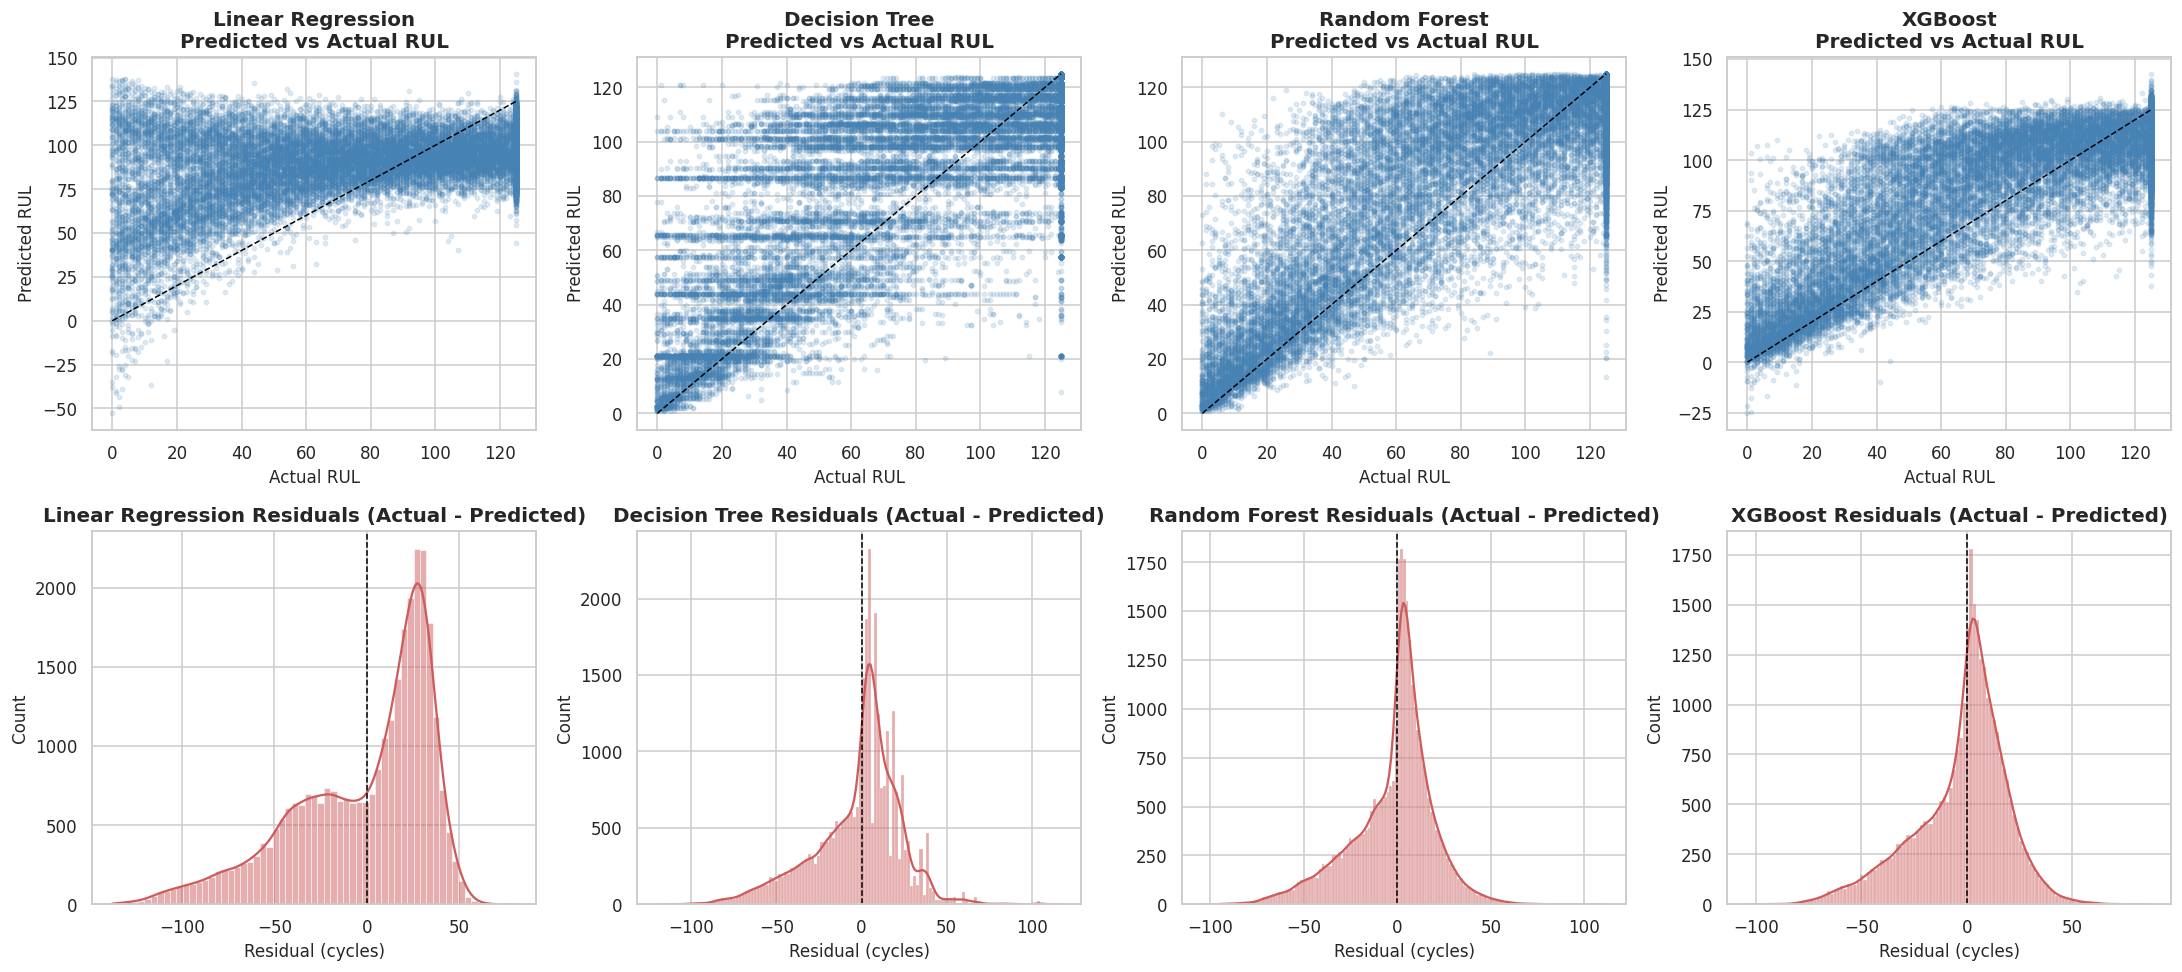

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for i, (name, r) in enumerate(results.items()):
    residuals = y_test - r["y_test_pred"]

    axes[0, i].scatter(y_test, r["y_test_pred"], alpha=0.15, s=8, color="steelblue")
    axes[0, i].plot([0, RUL_CLIP], [0, RUL_CLIP], color="black", linestyle="--", linewidth=1)
    axes[0, i].set_title(f"{name}\nPredicted vs Actual RUL")
    axes[0, i].set_xlabel("Actual RUL")
    axes[0, i].set_ylabel("Predicted RUL")

    sns.histplot(residuals, kde=True, ax=axes[1, i], color="indianred")
    axes[1, i].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[1, i].set_title(f"{name} Residuals (Actual - Predicted)")
    axes[1, i].set_xlabel("Residual (cycles)")

plt.tight_layout()
plt.show()

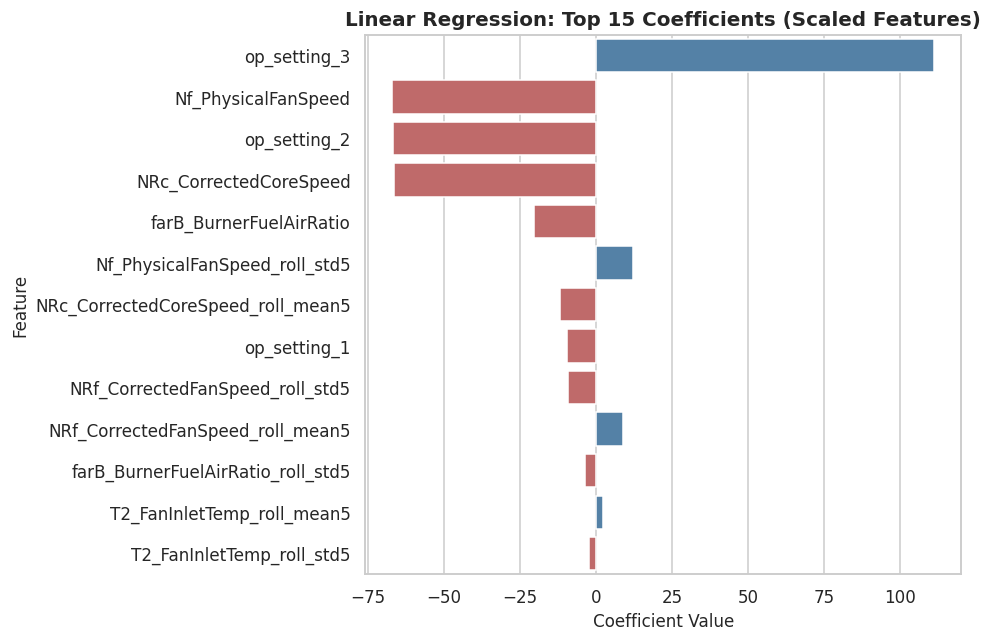

In [30]:
lr_coef_df = (
    pd.DataFrame({"feature": feature_cols, "coefficient": lr_model.coef_})
    .assign(abs_coefficient=lambda d: d["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=lr_coef_df, y="feature", x="coefficient",
    palette=["indianred" if c < 0 else "steelblue" for c in lr_coef_df["coefficient"]]
)
plt.title("Linear Regression: Top 15 Coefficients (Scaled Features)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

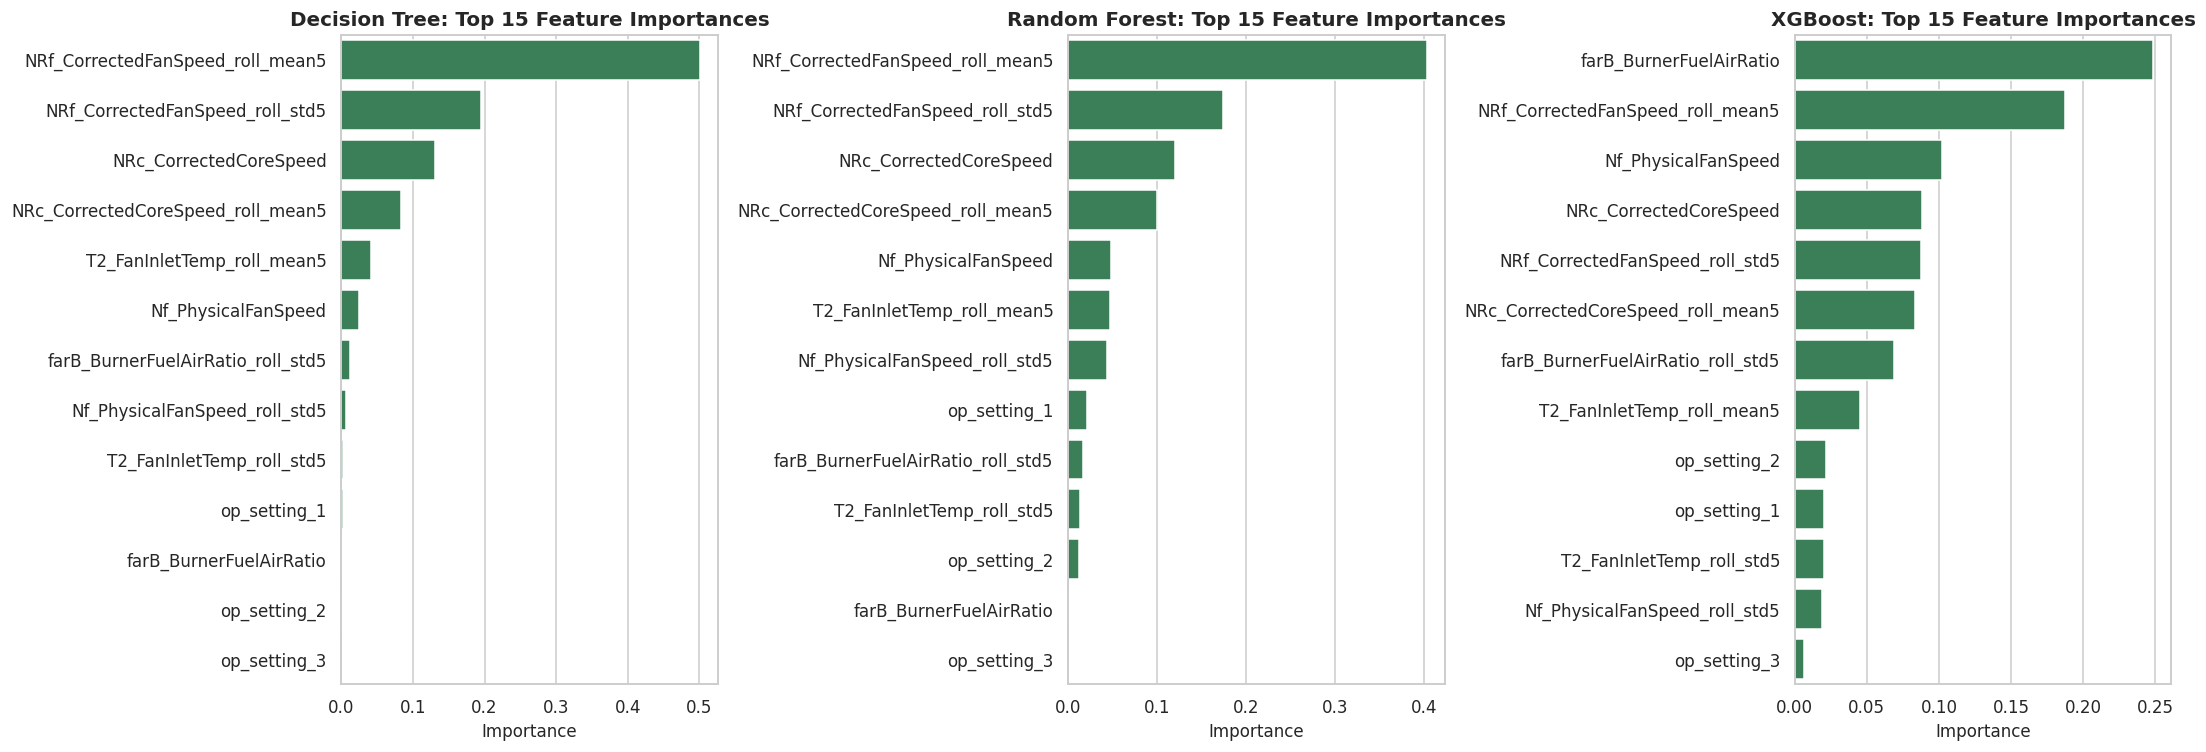

In [31]:
tree_models = {"Decision Tree": dt_model, "Random Forest": rf_model, "XGBoost": xgb_model}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (name, model) in zip(axes, tree_models.items()):
    importance_df = (
        pd.DataFrame({"feature": feature_cols, "importance": model.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(15)
    )
    sns.barplot(data=importance_df, y="feature", x="importance", ax=ax, color="seagreen")
    ax.set_title(f"{name}: Top 15 Feature Importances")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [32]:
metrics_df[["Test_RMSE", "Test_MAE", "Test_R2", "Overfit_Gap_RMSE"]].sort_values("Test_RMSE").round(3)

,Test_RMSE,Test_MAE,Test_R2,Overfit_Gap_RMSE
Model,,,,
Random Forest,21.951,15.904,0.719,7.300
XGBoost,22.051,16.313,0.716,0.831
Decision Tree,25.534,18.807,0.619,0.202
Linear Regression,37.412,30.640,0.183,1.040


# 10. Save Model for Deployment

In [33]:
model_filename = 'xgboost_rul_model.json'
xgb_model.save_model(model_filename)

features_filename = 'model_features.pkl'
joblib.dump(feature_cols, features_filename)

print("Model saved natively as JSON!")

Model saved natively as JSON!


In [34]:
test_df.to_csv('processed_test_sample.csv', index=False)
print("File saved successfully! Please download 'processed_test_sample.csv'")

File saved successfully! Please download 'processed_test_sample.csv'
